In [1]:
!pip install networkx matplotlib

Struktur Data Graf dan Algoritma

In [2]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

def dijkstra_with_paths(graph, start):
    distances = {node: float('inf') for node in graph}
    distances[start] = 0
    previous = {node: None for node in graph}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        for neighbor, weight in graph[current_node].items():
            distance = current_distance + weight
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    return distances, previous

Rekontruksi Jalur

In [3]:
def get_path(previous, target):
    path = []
    while target is not None:
        path.insert(0, target)
        target = previous[target]
    return path

Visualisasi dengan Networkx dan Matplotlib


In [18]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_weight='bold',
        arrows=True
    )
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels
    )

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(
            G, pos,
            edgelist=path_edges,
            edge_color='red',
            width=3
        )

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

Penggunaan Lengkap

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


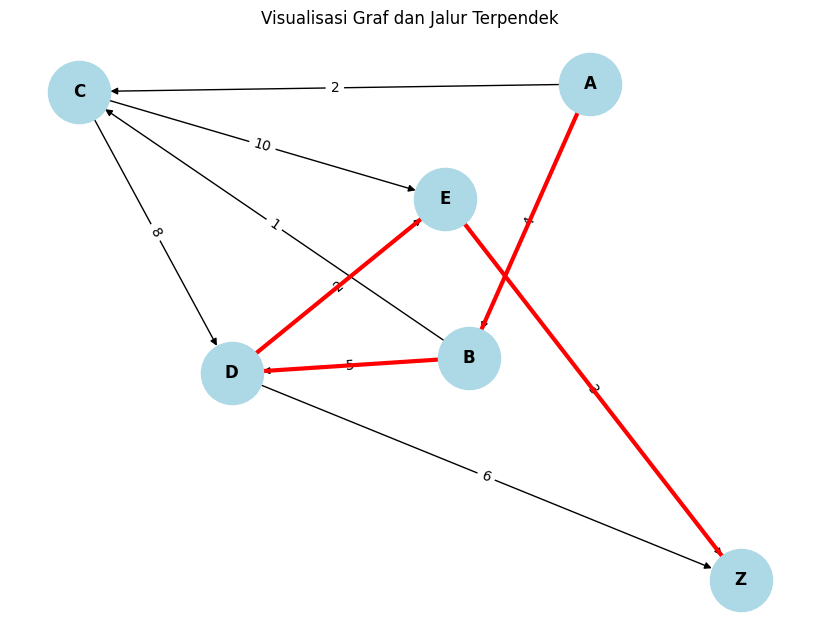

In [19]:
# Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)

Soal 1. Modifikasi graf agar memiliki siklus

Jarak: 14
Jalur: A -> B -> D -> E -> Z


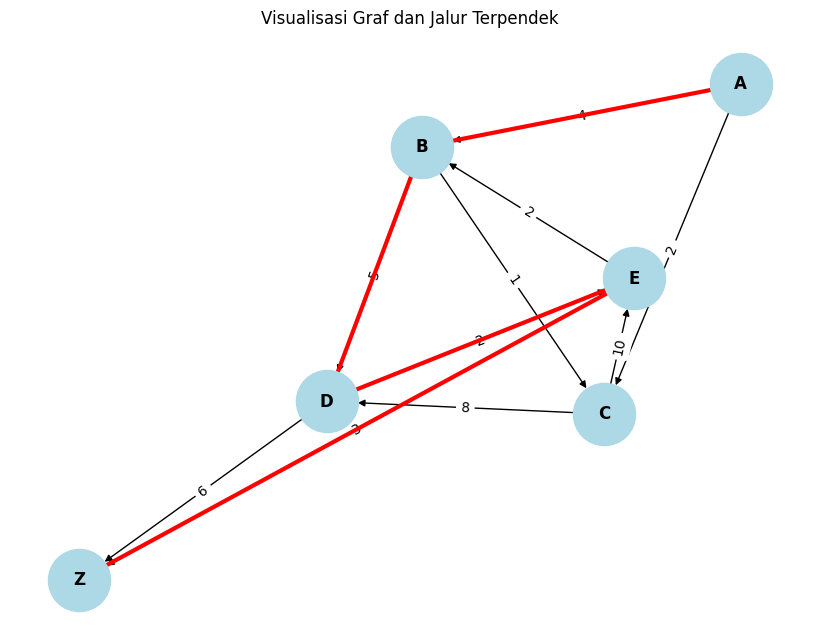

In [9]:
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'B': 2},  # Siklus E -> B
    'Z': {}
}

distances, previous = dijkstra_with_paths(graph, 'A')
shortest_path = get_path(previous, 'Z')

print(f"Jarak: {distances['Z']}")
print(f"Jalur: {' -> '.join(shortest_path)}")

visualize_graph(graph, path=shortest_path)

Soal 2. Tambahkan simpul baru

Jarak: 13
Jalur: A -> B -> D -> E -> F -> Z


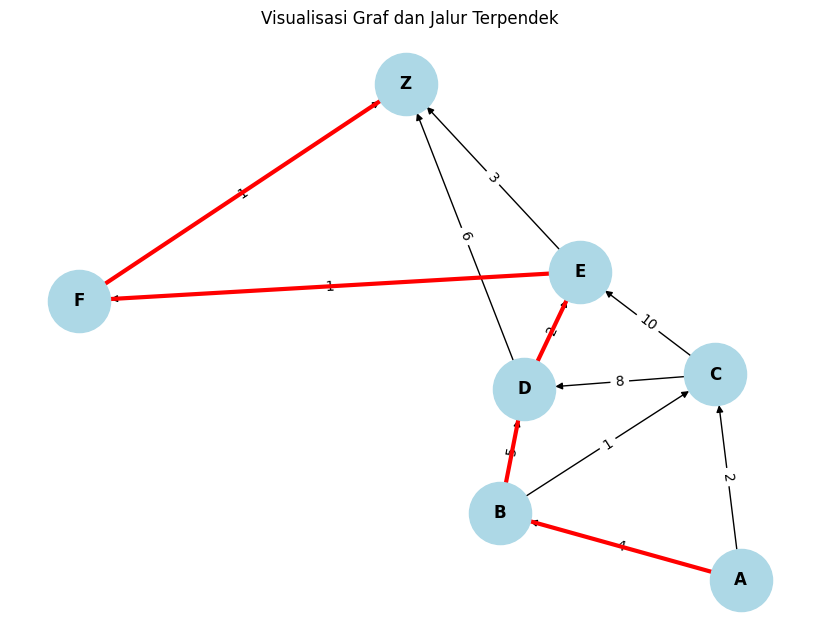

In [11]:
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3, 'F': 1},
    'F': {'Z': 1},
    'Z': {}
}

distances, previous = dijkstra_with_paths(graph, 'A')
shortest_path = get_path(previous, 'Z')

print(f"Jarak: {distances['Z']}")
print(f"Jalur: {' -> '.join(shortest_path)}")

visualize_graph(graph, path=shortest_path)

Jarak dari A ke Z: 14
Jalur: A -> B -> D -> E -> Z


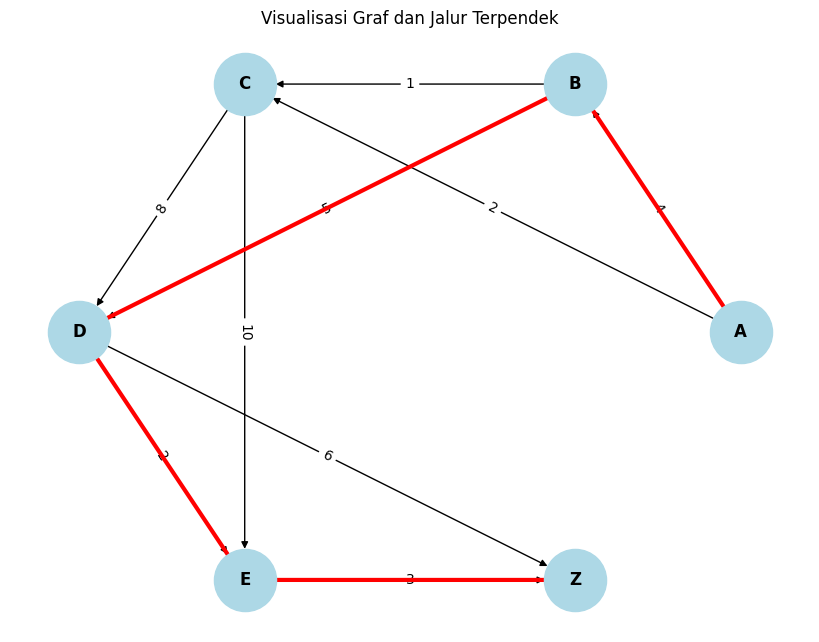

In [16]:
def visualize_graph(graph, path=None):
    G = nx.DiGraph()

    for node in graph:
        for neighbor, weight in graph[node].items():
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.circular_layout(G)
    edge_labels = nx.get_edge_attributes(G, 'weight')

    plt.figure(figsize=(8, 6))
    nx.draw(
        G, pos,
        with_labels=True,
        node_color='lightblue',
        node_size=2000,
        font_weight='bold',
        arrows=True
    )
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels
    )

    # Garis tebal untuk jalur terpendek
    if path and len(path) > 1:
        path_edges = list(zip(path, path[1:]))
        nx.draw_networkx_edges(
            G, pos,
            edgelist=path_edges,
            edge_color='red',
            width=3
        )

    plt.title("Visualisasi Graf dan Jalur Terpendek")
    plt.axis('off')
    plt.show()

    # Definisi graf
graph = {
    'A': {'B': 4, 'C': 2},
    'B': {'C': 1, 'D': 5},
    'C': {'D': 8, 'E': 10},
    'D': {'E': 2, 'Z': 6},
    'E': {'Z': 3},
    'Z': {}
}

# Jalankan Dijkstra
start_node = 'A'
end_node = 'Z'
distances, previous = dijkstra_with_paths(graph, start_node)

# Rekonstruksi jalur
shortest_path = get_path(previous, end_node)
print(f"Jarak dari {start_node} ke {end_node}: {distances[end_node]}")
print(f"Jalur: {' -> '.join(shortest_path)}")

# Visualisasi
visualize_graph(graph, path=shortest_path)